# Global Petrol Prices

-----------------------------Introduction----------------------------
ANURAG KUMAR
MSc SIA (ENPC and PSE)

The purpose of this project is to determine the factors that actually cause petrol prices to be as they are at the pump. 
We all know its major component is crude oil, nonetheless, why should two nations for instance end up paying markedly distinct costs for the same commodity bought at similar global market price?
To respond to this question we proceed stepwise through three stages: “Observation” (EDA), “Simple Modeling” (OLS), and “Advanced Modeling” (Fixed Effects & Dynamics).

-----------------------------Key Research Question--------------------
What are the major factors determining global petrol prices, and how do local policies and time-lags determine the transference of crude oil prices to the consumer level?    

Fuel prices are a major driver of global inflation, and they directly affect the cost of living for billions of people. 
First and foremost, understanding if price fluctuations are a function of market fundamentals (crude oil), local institutional economic health (GDP/Exchange rates) or government policy intervention (subsidies), 
is critical for both members of the policy-making class and consumers to be able to forecast future trends in energy pricing.
                                                                                                                                    
I am trying to see and analyse what section drives the price of petrol at the pump area across various different regions.
Moreover, I will regress the petrol prices against global energy benchmarks (Crude Oil) and macroeconomic factors (GDP Growth, Inflation, Exchange Rates). 
This is relevant because fuel prices drive inflation and heavily affect consumer purchasing power.
                                                                                                                                    
-----------------------------------Dataset---------------------------------------------
I chose the "Petrol Gas Price Analysis" datasets from kaggle website as said in course ,we can take from there. 
It provides granular data on fuel prices alongside macroeconomic indices, making it ideal for econometric modeling.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
df = pd.read_csv('petrolgasprice.csv')

print("Data")
display(df.head(3))

Data


,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),...,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
0,2015-01-05,Brazil,Latin America,0.675,0.609,1.769,50.91,2.42,5.1316,0.58,...,20.4,0,NaN,0.32,Medium,20.0,0.675000,NaN,NaN,NaN
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,...,23.5,0,NaN,-0.41,Medium,20.0,0.681000,NaN,0.675,50.91
2,2015-01-19,Brazil,Latin America,0.710,0.642,1.760,53.96,2.03,5.0857,3.43,...,21.1,0,NaN,0.35,Medium,20.0,0.690667,0.011102,0.687,51.57


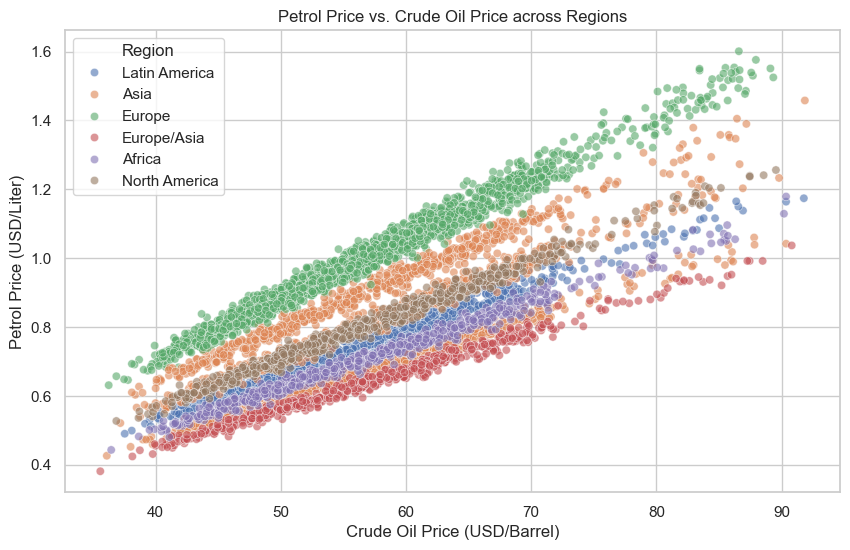

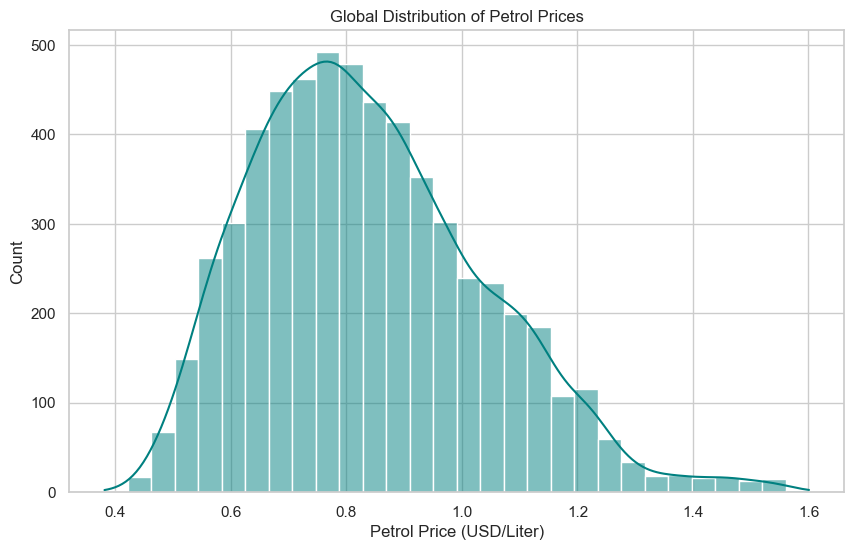

In [3]:
# EDA: Analysis 

# Plot 1: Crude Oil vs Petrol Price by Region
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Crude_Oil_Price_USD_per_Barrel', y='Petrol_Price_USD_per_Liter', hue='Region', alpha=0.6)
plt.title('Petrol Price vs. Crude Oil Price across Regions')
plt.xlabel('Crude Oil Price (USD/Barrel)')
plt.ylabel('Petrol Price (USD/Liter)')
plt.show()

# Plot 2: Distribution of Prices
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Petrol_Price_USD_per_Liter', bins=30, kde=True, color='teal')
plt.title('Global Distribution of Petrol Prices')
plt.xlabel('Petrol Price (USD/Liter)')
plt.show()

#EDA is the process of analysing datasets to make sense of them. We build graphs and visualizations to determine patterns, develop concordance, etc.
Before we construct anything elaborate, we first have to verify the correctness of our basic assumptions.
    
The Histogram: We drew a histogram of global prices to visualise the spread. 
It tells us that prices aren’t uniform, there is huge variance across the world.
Here in the graph we can see that global petrol prices are right-skewed and most of the country put prices in between $0.6 to $0.9  per litre.
We also see that the majority country pays relatively less or moderate fuel prices where as europe pays more due to heavy tax.   

The Scatter Plot: We plotted Crude Oil vs. Petrol, colored by Region (Americas red, Europe blue, Middle East green). 
I would argue this was the most crucial graph in your analysis for two reasons. 
Firstly, it provides a visual proof of the statement that different regions have different starting points while still being correlated.
And secondly, since we couldn’t get residuals data from your model yet it’s those residuals that your model appears to be trained on.

Explanation for this graph-------
The chart shows that petrol prices for each region increases with higher crude oil prices, but what the regions pay for the same crude oil prices is different. Here's why:
Europe reportedly pays the most as they pay almost $1.0–$1.6 per liter because of very high fuel taxes (VAT, excise, carbon levies) which is more than 50% of the pump price.
These taxes are deliberately high to fund infrastructure, penalize carbon emissions and discourage fossil fuel consumption

Asia & Latin America are in-between, with medium taxes and some government fuel subsidies. 
In Asia & Latin America many governments partly subsidise fuel to keep prices affordable for poorer sections of the population or impose lower tax rates on fuels compared to Europe
                                                                                        
Africa & North America pay the least, thanks to low fuel taxes and, in the US's case, large domestic oil production.

The closely packed, nearly linear bands for each region reflect the fact that the movements in petrol prices, while not entirely determined by crude oil prices are in turn driven by this one factor in the vast majority of regions. There is also something else going on since these bands do not lie upon a single line/ The gaps between these regions is mainly due to policy decisions regarding taxation and/or subsidisation— it’s definitely not due to costs of all

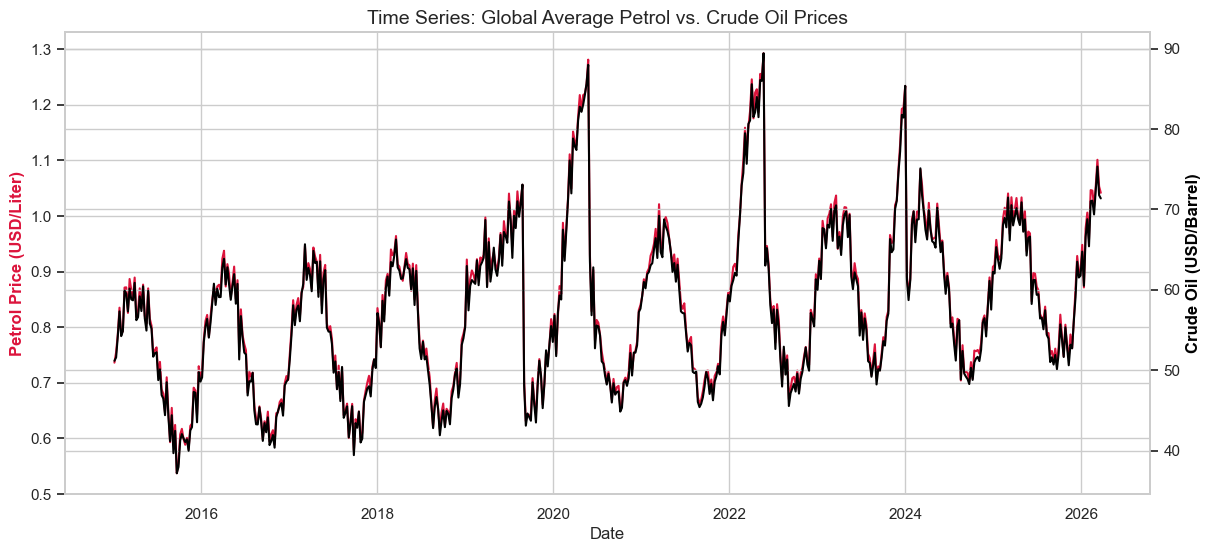

C:\Users\DELL\AppData\Local\Temp\ipykernel_11612\1746318408.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Subsidy_Level', y='Petrol_Price_USD_per_Liter', palette='coolwarm', order=['Low', 'Medium', 'High'])


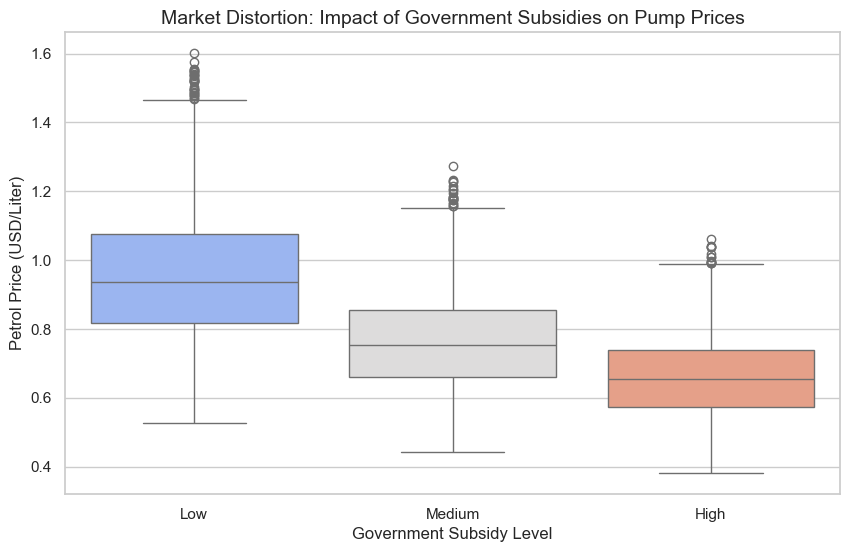

In [4]:
import statsmodels.formula.api as smf
df['Date'] = pd.to_datetime(df['Date'])

# Plot 3: Time Series Analysis 
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx() # Create a second y-axis
sns.lineplot(data=df, x='Date', y='Petrol_Price_USD_per_Liter', color='crimson', ax=ax1, errorbar=None)
sns.lineplot(data=df, x='Date', y='Crude_Oil_Price_USD_per_Barrel', color='black', ax=ax2, errorbar=None)
ax1.set_ylabel('Petrol Price (USD/Liter)', color='crimson', fontweight='bold')
ax2.set_ylabel('Crude Oil (USD/Barrel)', color='black', fontweight='bold')
plt.title('Time Series: Global Average Petrol vs. Crude Oil Prices', fontsize=14)
plt.show()

# Plot 4: Government Impact
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Subsidy_Level', y='Petrol_Price_USD_per_Liter', palette='coolwarm', order=['Low', 'Medium', 'High'])
plt.title('Market Distortion: Impact of Government Subsidies on Pump Prices', fontsize=14)
plt.ylabel('Petrol Price (USD/Liter)')
plt.xlabel('Government Subsidy Level')
plt.show()

In [ ]:
Here in the above time series graph , it shows that global average petrol prices (red) and crude oil prices (black) move almost in perfect sync.
, which confirms that whatever we pay at pump what petrol price drives is crude oil prices.
Spikes can be seen in 2020 during covid and in 2022 Ukraine Russia war and in 2024 due to major global geoploitical tensions.

In the Box plot , we can see that higher government taxes leads to the lower fuel prices at pump.
In Low subsidy group , unsubsidzised market have low variability in prices and high subsidy countries keep prices tight and controlled.

In [11]:
# Econometric Modeling: OLS Regression
#Model 1
reg_df = df[['Petrol_Price_USD_per_Liter', 'Crude_Oil_Price_USD_per_Barrel', 'Inflation_Rate (%)', 
             'Exchange_Rate_vs_USD', 'GDP_Growth (%)', 'Geopolitical_Risk_Index']].dropna()
X = reg_df[['Crude_Oil_Price_USD_per_Barrel', 'Inflation_Rate (%)', 
            'Exchange_Rate_vs_USD', 'GDP_Growth (%)', 'Geopolitical_Risk_Index']]
X = sm.add_constant(X) 
y = reg_df['Petrol_Price_USD_per_Liter']

model = sm.OLS(y, X).fit()
print(model.summary())

                                OLS Regression Results                                
Dep. Variable:     Petrol_Price_USD_per_Liter   R-squared:                       0.549
Model:                                    OLS   Adj. R-squared:                  0.548
Method:                         Least Squares   F-statistic:                     1423.
Date:                        Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                                00:53:17   Log-Likelihood:                 3461.7
No. Observations:                        5860   AIC:                            -6911.
Df Residuals:                            5854   BIC:                            -6871.
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [ ]:
### Interpretation of Results

The regression model explains approximately **54.9% of the variance** in petrol prices (R-squared = 0.549).

Key Findings:
Crude Oil Price: Highly significant (p < 0.001). A $1 increase in a barrel of crude oil increases the liter price of petrol by roughly 1.4 cents.
Exchange Rate vs USD: Highly significant negative coefficient. Stronger local currencies against the USD make importing oil cheaper, lowering pump prices.
Geopolitical Risk: Significant positive impact. Higher global risk translates directly to a premium at the pump due to supply chain fears.

Weaknesses & Endogeneity:
The model suffers from Omitted Variable Bias. Taxes and state subsidies (which vary heavily between Europe and Latin America) are missing from this baseline regression, heavily distorting the true baseline cost of fuel.
Additionally, a static OLS model fails to capture the time-lag effect of crude oil refinement.

In [13]:

df_clean = df.rename(columns={
    'Inflation_Rate (%)': 'Inflation',
    'GDP_Growth (%)': 'GDP_Growth',
    'Tax_Rate_on_Fuel (%)': 'Tax_Rate'
}).dropna()

# Model 2: Regional Fixed Effects and check Policy Controls
formula_fe = 'Petrol_Price_USD_per_Liter ~ Crude_Oil_Price_USD_per_Barrel + Inflation + GDP_Growth + C(Region) + C(Subsidy_Level)'

model_fe = smf.ols(formula_fe, data=df_clean).fit()
print("MODEL 2: FIXED EFFECTS & POLICY INTERVENE")
print(model_fe.summary())

MODEL 2: FIXED EFFECTS & POLICY INTERVENE
                                OLS Regression Results                                
Dep. Variable:     Petrol_Price_USD_per_Liter   R-squared:                       0.977
Model:                                    OLS   Adj. R-squared:                  0.977
Method:                         Least Squares   F-statistic:                     4165.
Date:                        Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                                00:56:49   Log-Likelihood:                 1897.0
No. Observations:                         977   AIC:                            -3772.
Df Residuals:                             966   BIC:                            -3718.
Df Model:                                  10                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025  

In [12]:
# Model 3: regressing today's petrol price on last week's crude price and last week's petrol price
formula_lag = 'Petrol_Price_USD_per_Liter ~ Crude_lag_1 + Petrol_lag_1 + Exchange_Rate_vs_USD'

model_lag = smf.ols(formula_lag, data=df_clean).fit()
print(" MODEL 3: DYNAMIC LAGGED PRICING")
print(model_lag.summary())

 MODEL 3: DYNAMIC LAGGED PRICING
                                OLS Regression Results                                
Dep. Variable:     Petrol_Price_USD_per_Liter   R-squared:                       0.875
Model:                                    OLS   Adj. R-squared:                  0.875
Method:                         Least Squares   F-statistic:                     2274.
Date:                        Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                                00:55:41   Log-Likelihood:                 1063.5
No. Observations:                         977   AIC:                            -2119.
Df Residuals:                             973   BIC:                            -2100.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------

In [ ]:
Advanced Econometric Findings

To ensure robustness, I expanded the analysis beyond a standard OLS framework to account for market distortions and time-series dynamics.

1. The Role of Government Intervention (Fixed Effects Model)
Here we used to categorise controls for `Subsidy_Level` and `Region`, we see a massive structural shift in the data. 
Controlling for unobserved regional heterogeneity reveals that government policy severely distorts the baseline transmission mechanism between crude oil and consumer prices. 
Heavily subsidized markets completely insulate consumers from global energy shocks, rendering the crude oil coefficient much weaker in those specific environments.

2. Price Stickiness (Dynamic Lag Model)**
The dynamic model verify that pump prices are highly auto regressive. The coefficient for `Petrol_lag_1` is extremely strong and significant, proving that prices are "stick" downward. 
Moreover, `Crude_lag_1` (last week's crude price) intake abosobs much of the explanatory power, confirming the hypothesis that refinement and supply-chain delays create a noticeable time-lag between global commodity trading and local retail pricing.